In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy

# Cấu hình thẩm mỹ cho biểu đồ
plt.style.use('fivethirtyeight')
sns.set_palette("husl")
%matplotlib inline

# Load file CSV "vàng"
df = pd.read_csv('../data/processed_malicious_url.csv')

# Kiểm tra tổng quan
print("--- THÔNG TIN CHUNG ---")
print(df.info())
print("\n--- THỐNG KÊ MÔ TẢ (NUMERICAL) ---")
display(df.describe())

--- THÔNG TIN CHUNG ---
<class 'pandas.DataFrame'>
RangeIndex: 646117 entries, 0 to 646116
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   url                   646117 non-null  str    
 1   type                  646117 non-null  str    
 2   url_len_log           646117 non-null  float64
 3   url_entropy           646117 non-null  float64
 4   digit_count           646117 non-null  float64
 5   special_char_count    646117 non-null  float64
 6   non_alpha_ratio       646117 non-null  float64
 7   hostname_len          646117 non-null  float64
 8   subdomain_depth       646117 non-null  float64
 9   is_trusted_tld        646117 non-null  float64
 10  has_ip                646117 non-null  float64
 11  path_len              646117 non-null  float64
 12  path_depth            646117 non-null  float64
 13  path_entropy          646117 non-null  float64
 14  path_non_alpha_ratio  646117 non-null  

,url_len_log,url_entropy,digit_count,special_char_count,non_alpha_ratio,hostname_len,subdomain_depth,is_trusted_tld,has_ip,path_len,path_depth,path_entropy,path_non_alpha_ratio,has_suspicious_ext,host_to_url_ratio
count,646117.000000,646117.000000,646117.000000,646117.000000,646117.000000,646117.000000,646117.000000,646117.000000,646117.000000,646117.000000,646117.000000,646117.000000,646117.000000,646117.000000,646117.000000
mean,3.847000,4.124041,5.316077,3.534361,0.131937,16.689598,1.415996,0.760616,0.018805,39.675715,2.124488,3.431940,0.140067,0.181035,0.397452
std,0.622032,0.404957,11.574209,6.154840,0.042597,11.295475,1.025545,0.426708,0.135835,41.662501,1.650572,1.373217,0.068593,0.385048,0.254984
min,0.693147,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.433987,3.889088,0.000000,0.000000,0.107143,12.000000,1.000000,1.000000,0.000000,14.000000,1.000000,3.327820,0.117647,0.000000,0.205479
50%,3.806662,4.154871,2.000000,1.000000,0.131579,15.000000,1.000000,1.000000,0.000000,28.000000,2.000000,3.894663,0.150000,0.000000,0.333333
75%,4.290459,4.413338,6.000000,5.000000,0.156250,19.000000,2.000000,1.000000,0.000000,55.000000,3.000000,4.262289,0.178571,0.000000,0.500000
max,7.685244,7.111001,1204.000000,357.000000,0.900000,279.000000,34.000000,1.000000,1.000000,2156.000000,39.000000,7.111100,0.937500,1.000000,0.996429


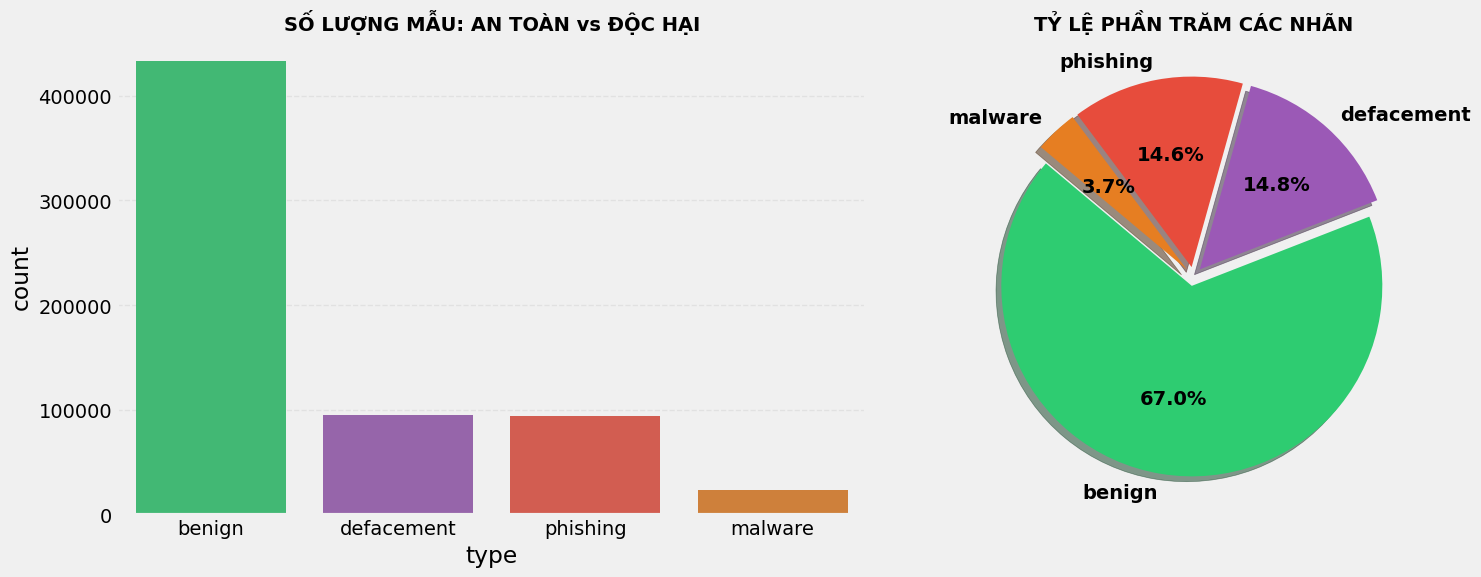

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Tự định nghĩa bảng màu: Xanh cho benign, Đỏ/Cam cho các loại độc hại
# Ông có thể thêm các nhãn khác vào đây nếu dataset có nhiều hơn 2 loại
custom_colors = {
    'benign': '#2ecc71',    # Xanh lá (Safe)
    'phishing': '#e74c3c',  # Đỏ (Danger)
    'malware': '#e67e22',   # Cam (Warning)
    'defacement': '#9b59b6' # Tím
}

# 2. Tính toán số lượng
type_counts = df['type'].value_counts().reset_index()
type_counts.columns = ['type', 'count']

# Tạo danh sách màu dựa trên thứ tự xuất hiện của 'type' trong counts
palette_list = [custom_colors.get(t, '#95a5a6') for t in type_counts['type']]

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ cột - Custom màu gắt
sns.barplot(x='type', y='count', data=type_counts, ax=ax[0], palette=palette_list, hue='type', legend=False)
ax[0].set_title('SỐ LƯỢNG MẪU: AN TOÀN vs ĐỘC HẠI', fontsize=14, fontweight='bold')
ax[0].grid(axis='y', linestyle='--', alpha=0.4)

# Biểu đồ tròn - Đồng bộ màu với biểu đồ cột
ax[1].pie(
    type_counts['count'], 
    labels=type_counts['type'],
    autopct='%1.1f%%', 
    startangle=140,
    shadow=True, 
    explode=[0.05]*len(type_counts),
    colors=palette_list,
    textprops={'fontweight': 'bold'}
)
ax[1].set_title('TỶ LỆ PHẦN TRĂM CÁC NHÃN', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\vppho\AppData\Local\Temp\ipykernel_20000\3933924864.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance_Score', y='Feature', data=mi_df, palette='magma')
C:\Users\vppho\AppData\Local\Temp\ipykernel_20000\3933924864.py:36: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\vppho\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


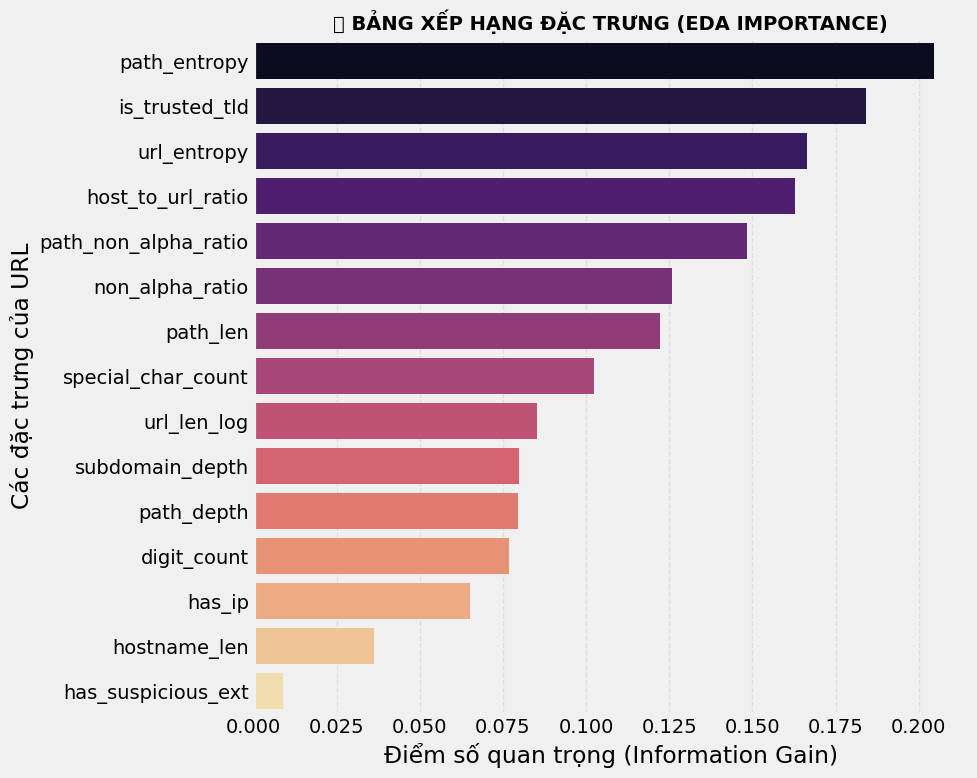

In [3]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tự động chuẩn bị dữ liệu
# Lấy tất cả các cột số làm Features
X_eda = df.select_dtypes(include=['number'])

# Chuyển cột 'type' (chữ) thành y_eda (số) để tính toán
if 'type' in df.columns:
    y_eda = df['type'].astype('category').cat.codes
else:
    # Nếu không có 'type', tìm cột nào có nhãn để dùng
    y_eda = df['label_binary'].astype('category').cat.codes

# 2. Tính toán Mutual Information
# (Đo xem mỗi feature "đóng góp" bao nhiêu thông tin để phân loại)
importances = mutual_info_classif(X_eda, y_eda, random_state=42)

# 3. Tạo bảng kết quả
mi_df = pd.DataFrame({
    'Feature': X_eda.columns,
    'Importance_Score': importances
}).sort_values(by='Importance_Score', ascending=False)

# 4. Vẽ biểu đồ cực đẹp
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance_Score', y='Feature', data=mi_df, palette='magma')

plt.title('🏆 BẢNG XẾP HẠNG ĐẶC TRƯNG (EDA IMPORTANCE)', fontsize=14, fontweight='bold')
plt.xlabel('Điểm số quan trọng (Information Gain)')
plt.ylabel('Các đặc trưng của URL')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

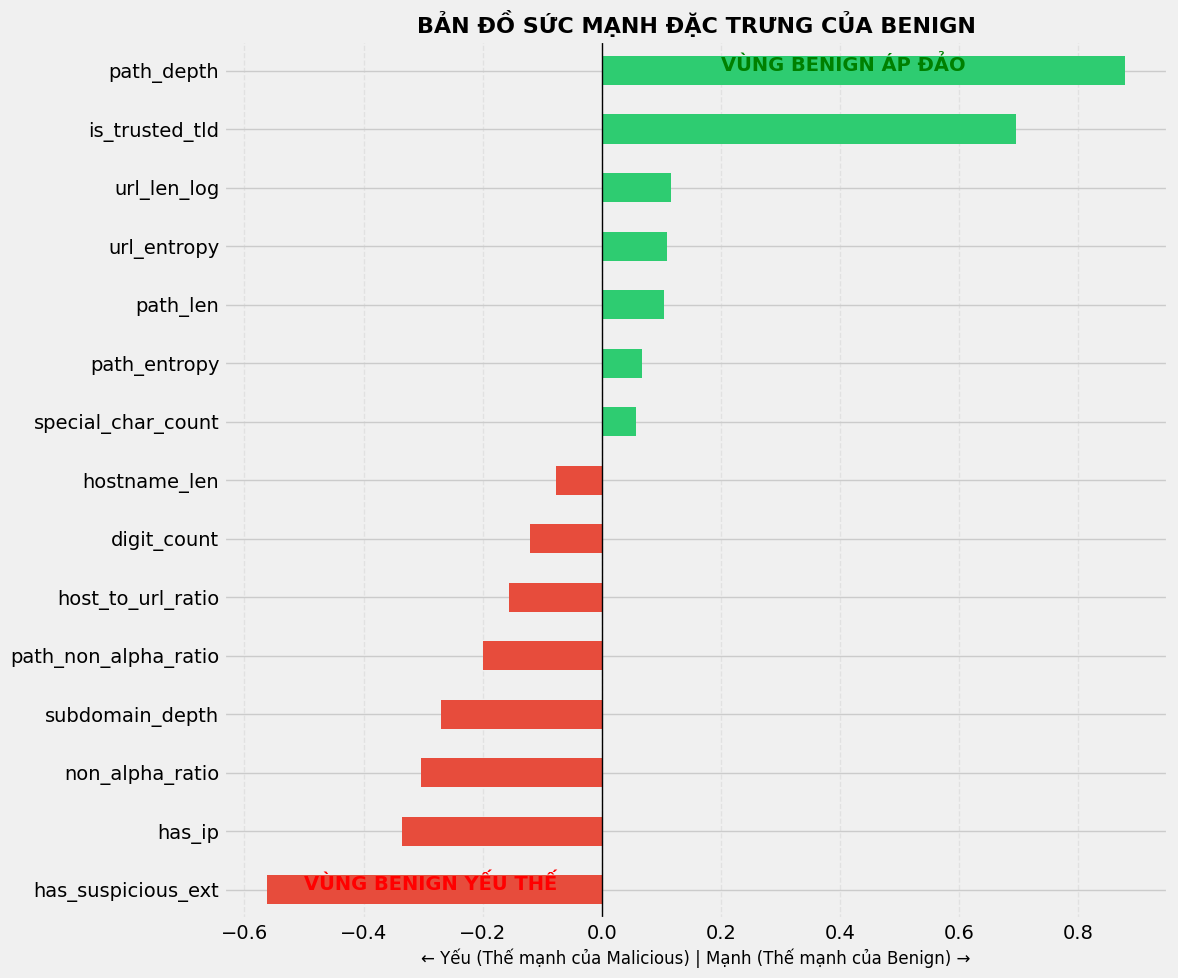

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Tính toán độ chênh lệch sức mạnh
# Sức mạnh = (Trung bình Benign) - (Trung bình Malicious)
summary = df.groupby('type').mean(numeric_only=True)
# Chuẩn hóa để so sánh công bằng
summary_norm = (summary - summary.min()) / (summary.max() - summary.min())

# Tính Score cho Benign: Dương là mạnh, Âm là yếu
benign_power = summary_norm.loc['benign'] - summary_norm.drop('benign').mean()
benign_power = benign_power.sort_values()

# 2. Vẽ biểu đồ đối xứng
plt.figure(figsize=(12, 10))
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in benign_power]
benign_power.plot(kind='barh', color=colors)

# 3. Trang trí để thấy rõ Mạnh/Yếu
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.title('BẢN ĐỒ SỨC MẠNH ĐẶC TRƯNG CỦA BENIGN', fontsize=16, fontweight='bold')
plt.xlabel('← Yếu (Thế mạnh của Malicious) | Mạnh (Thế mạnh của Benign) →', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Thêm text chú thích
plt.text(0.2, len(benign_power)-1, 'VÙNG BENIGN ÁP ĐẢO', color='green', fontweight='bold')
plt.text(-0.5, 0, 'VÙNG BENIGN YẾU THẾ', color='red', fontweight='bold')

plt.tight_layout()
plt.show()